# NB03b · PPO Baseline PyTorch (SB3 RolloutBuffer)

Agent **Proximal Policy Optimization** (Schulman et al. 2017) implementat en PyTorch pur.
Usa `stable_baselines3.common.buffers.RolloutBuffer` per a un GAE idèntic al de SB3,
però la xarxa, l'algorisme i el bucle d'entrenament estan implementats manualment
per permetre **visibilitat interna** (activacions per capa, gradient hooks) necessària per a HRL.

| Secció | Contingut |
|--------|-----------|
| 1 | Configuració i càrrega de dades via `DataManager` |
| 2 | **CustomPPO** (PyTorch) + `ActorCriticPolicy` (HRL-ready) |
| 3 | Entrenament amb hiperparàmetres de NB03a |
| 4 | Avaluació **walk-forward** sobre el test split |
| 5 | Robustesa a la inicialització (N=20 runs) |

**Protocol d'avaluació**: walk-forward estricte train < val < test (ordre temporal).
Les comissions Kraken estan incloses a l'entorn importat de `src/rl/envs`.

## Equivalència amb NB03a (SB3 PPO)

| Component SB3 | Component NB03b |
|---|---|
| `stable_baselines3.PPO` | `CustomPPO` (aquest notebook) |
| `MlpPolicy` | `ActorCriticPolicy` (nn.Module, HRL-ready) |
| `MlpExtractor.policy_net` | `ActorCriticPolicy.policy_net` |
| `MlpExtractor.value_net`  | `ActorCriticPolicy.value_net` |
| `RolloutBuffer` (SB3)     | `RolloutBuffer` (SB3, importat directament) |
| `BaseCallback` (SB3)      | `BaseCallback` (SB3, importat directament) |
| Init ortogonal √2/0.01/1  | idèntic a SB3 |
| Adam eps=1e-5             | idèntic a SB3 | (Sparse Reward)


In [12]:
# =============================================================================
# CEL·LA 1 — IMPORTS
# =============================================================================

import copy
import json
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from codecarbon import EmissionsTracker
from torch.distributions import Categorical
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm

# ── Gymnasium spaces (per a RolloutBuffer) ───────────────────────────────────
from gymnasium import spaces

# ── SB3: RolloutBuffer i callbacks (NO la classe PPO) ────────────────────────
from stable_baselines3.common.buffers import RolloutBuffer
from stable_baselines3.common.callbacks import BaseCallback

# ── Project ───────────────────────────────────────────────────────────────────
from src.data.manager import DataManager
from src.rl.envs.crypto_market_env_consolidated_reward import (
    CryptoMarketEnvConsolidatedReward, INITIAL_BALANCE, MAX_EPISODE_STEPS, MIN_EPISODE_STEPS,
     LOG_COLS,
    HOLD_PENALTY, DD_THRESHOLD, DD_PENALTY, OPEN_POSITION_PENALTY,
     steps_per_4h_for,
)
from src.rl.metrics import compute_sharpe, compute_max_drawdown
from src.rl.utils import narrow, narrow_int, fee_curriculum_factor
from src.rl.visualization import plot_optuna_search, plot_training_curves, plot_walk_forward
from src.rl.model_summary import model_summary

# Pre-training support
from src.rl.training.pretrain_hrl import PreTrainingConfig, SyntheticPhaseConfig
from src.rl.training.synthetic_data import make_synthetic_df

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
print("Imports OK")


Imports OK


In [13]:
# =============================================================================
# CEL·LA 2 — CONFIGURACIÓ: SEED, DEVICE, PATHS
# =============================================================================

import os as _os

# Reproducibilitat
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# CWD: suport Jupyter des de qualsevol directori
_cwd = Path.cwd()
if not (_cwd / "data" / "processed").exists():
    _root = _cwd.parents[1]
    if (_root / "data" / "processed").exists():
        _os.chdir(_root)
        print(f"CWD -> {_root}")

# Paths
CHECKPOINTS    = Path("checkpoints_sparse"); CHECKPOINTS.mkdir(exist_ok=True)
RESULTS        = Path("results_sparse") / "03s_ppo_baseline_agent"; RESULTS.mkdir(parents=True, exist_ok=True)
RUNS_DIR       = RESULTS / "runs"; RUNS_DIR.mkdir(parents=True, exist_ok=True)
CODECARBON_DIR = RESULTS / "codecarbon"; CODECARBON_DIR.mkdir(parents=True, exist_ok=True)

# Timeframe i DataManager
TIMEFRAME = "60m"
PROJECT   = "nb03s_ppo_pytorch"  # identificador per als logs CSV
dm = DataManager(interval=TIMEFRAME, project_root=Path("."))

FEATURE_COLS = dm.features        # 65 Norm_* features
N_FEATURES   = len(FEATURE_COLS)  # 65

# Arquitectura de la xarxa neuronal (fixada, idèntica a NB03a)
N_LAYERS    = 2
N_HIDDEN    = 128
HIDDEN_DIMS = [max(N_HIDDEN // (2**i), 16) for i in range(N_LAYERS)]  # [128, 64]
print(f"Arquitectura: N_LAYERS={N_LAYERS}, N_HIDDEN={N_HIDDEN}, HIDDEN_DIMS={HIDDEN_DIMS}")

# Hiperparàmetres d'entrenament (idèntics a NB03a per comparabilitat)
TUNE_TIMESTEPS  = 1_000_000  # per trial Optuna
N_TRIALS        = 50        # trials Optuna (Fase 1)
N_STARTUP       = 15        # startup aleatoris (TPESampler + MedianPruner)
N_TRIALS_REFINE = 25        # trials Optuna (Fase 2 CMA-ES)
MIN_POSITION_FRAC = 0.30    # minim fraccio de steps en posicio; trials per sota -> descartats
PRUNE_WARMUP_FRAC = 0.40    # MedianPruner no actua abans del 40% dels timesteps d'un trial
FINAL_TIMESTEPS = 3_000_000 # entrenament final
EVAL_FREQ       = 50_000    # cada quants ts avaluem
N_EVAL_EPS      = 10        # episodis per avaluació

# Curriculum learning de comissions (fee_factor: 0.0 -> 1.0)
FEE_WARMUP_FRAC   = 0.40   # 40%: exploracio lliure sense fees
FEE_RAMP_END_FRAC = 0.60   # 60%: fi de la rampa, fees reals a partir d'aqui

# Mètrica objectiu Optuna: 'best_return' (default, historic) o 'sharpe_final'
# - 'best_return': max(val_returns) — premia peaks, pot caure en artefactes BAH
# - 'sharpe_final': mean(sharpe dels últims 3 evals) — premia policies estables
OPTUNA_OBJECTIVE = 'best_return'
N_EVAL_EPS_TUNE   = 5           # Reduït durant Optuna (50% estalvi)

# ── Custom prune (NOU) ───────────────────────────────────────────────────────
# Prune trials que després del warmup no mostren senyals de convergir.
# Basat en analisi de 18 trials: els trials dolents tenen:
#   - mean(val_return ultims 3 evals) negatiu a partir de 500K
#   - worker_entropy ~ 1.386 (uniform, no aprenentatge)
#   - worker_kl ~ 2e-5 (policy congelada)
CUSTOM_PRUNE_WARMUP       = 750_000   # 40% de TUNE_TIMESTEPS
CUSTOM_PRUNE_MIN_RET      = +0.5      # mean(last_3_evals) < +1.0% -> prune
CUSTOM_PRUNE_CHECK_POLICY = False      # activar policy-frozen pruner
CUSTOM_PRUNE_MAX_ENTROPY  = 1.10      # ln(3) ~= 1.10 (3 accions efectives)
CUSTOM_PRUNE_MIN_KL       = 5e-4      # KL < 5e-4 -> política estancada

# Longitud d'episodi variable (evita dependència del timeout)
VARIABLE_LENGTH = True
EP_STEPS_MIN    = MIN_EPISODE_STEPS  # 504 steps = 3 setmanes @60m (mínim per aprendre)
EP_STEPS_MAX    = 6_048              # 8760 steps = 1 any @60m (màxim entrenament)
EP_STEPS_EVAL   = MAX_EPISODE_STEPS  # 2016 steps fixos per avaluació (comparabilitat Optuna)


print(f"Features: {N_FEATURES}")
print(f"Reward: PnL-only (sparse — reward only on close)")
print(f"Penalitzacions: HOLD={HOLD_PENALTY}  DD_threshold={DD_THRESHOLD:.0%}  DD_penalty={DD_PENALTY}  OpenPosition={OPEN_POSITION_PENALTY}")


Device: cuda
Arquitectura: N_LAYERS=2, N_HIDDEN=128, HIDDEN_DIMS=[128, 64]
Features: 65
Reward: PnL-only (sparse — reward only on close)
Penalitzacions: HOLD=-2e-05  DD_threshold=20%  DD_penalty=-50.0  OpenPosition=-5.0


In [14]:
# ── Pre-training configuration ────────────────────────────────────────────────
PRE_TRAINING = True  # Set to True to enable synthetic pre-training
PRE_TRAIN_PHASE1_STEPS = 50_000   # Fixed frequency sine
PRE_TRAIN_PHASE2_STEPS = 50_000   # Chirp (frequency sweep)
PRE_TRAIN_PHASE3_STEPS = 100_000  # Fractal multi-frequency

# ── SMOKE TEST MODE ────────────────────────────────────────────────────────────
# Set to True for quick validation (2 trials, 500 steps each, 1k pre-train)
# Set to False for full optimization runs
SMOKE = False

if SMOKE:
    print("\n" + "="*80)
    print("WARNING: SMOKE TEST MODE ENABLED")
    print("Quick validation run: 2 trials, 500 timesteps, minimal pre-training")
    print("Set SMOKE=False for full optimization")
    print("="*80 + "\n")
    
    # Override training parameters for smoke test
    TUNE_TIMESTEPS = 500
    N_TRIALS = 2
    N_TRIALS_REFINE = 3
    FINAL_TIMESTEPS = 1_000
    
    # Override pre-training steps
    PRE_TRAIN_PHASE1_STEPS = 1_000
    PRE_TRAIN_PHASE2_STEPS = 1_000
    PRE_TRAIN_PHASE3_STEPS = 2_000
else:
    # Normal configuration (defined in previous cells or defaults)
    TUNE_TIMESTEPS = TUNE_TIMESTEPS if 'TUNE_TIMESTEPS' in globals() else 50_000
    N_TRIALS = N_TRIALS if 'N_TRIALS' in globals() else 30
    FINAL_TIMESTEPS = FINAL_TIMESTEPS if 'FINAL_TIMESTEPS' in globals() else 300_000


In [15]:
# =============================================================================
# CEL·LA 3 — CÀRREGA DE DADES
# =============================================================================

# Carrega via DataManager
df_train, df_val, df_test = dm.load_all()

# ── Load synthetic data if pre-training enabled ───────────────────────────────
if PRE_TRAINING:
    import polars as pl
    SYNTHETIC_DIR = Path("data/synthetic")
    df_synth_p1 = pl.read_parquet(SYNTHETIC_DIR / "phase1_fixed_freq.parquet")
    df_synth_p2 = pl.read_parquet(SYNTHETIC_DIR / "phase2_chirp.parquet")
    df_synth_p3 = pl.read_parquet(SYNTHETIC_DIR / "phase3_fractal.parquet")
    print(f"\nSynthetic data loaded:")
    print(f"  Phase 1: {len(df_synth_p1):,} steps (fixed freq)")
    print(f"  Phase 2: {len(df_synth_p2):,} steps (chirp)")
    print(f"  Phase 3: {len(df_synth_p3):,} steps (fractal)")
    print(f"  Total: {len(df_synth_p1) + len(df_synth_p2) + len(df_synth_p3):,} synthetic timesteps")
    print(f"\nPre-training schedule:")
    print(f"  Phase 1: {PRE_TRAIN_PHASE1_STEPS:,} training steps")
    print(f"  Phase 2: {PRE_TRAIN_PHASE2_STEPS:,} training steps")
    print(f"  Phase 3: {PRE_TRAIN_PHASE3_STEPS:,} training steps")
    print(f"  Real data: {TUNE_TIMESTEPS:,} + {FINAL_TIMESTEPS:,} steps\n")

print(f"Train: {len(df_train):>8,} files  "
      f"({df_train['timestamp'].min()} \u2192 {df_train['timestamp'].max()})")
print(f"Val:   {len(df_val):>8,} files  "
      f"({df_val['timestamp'].min()} \u2192 {df_val['timestamp'].max()})")
print(f"Test:  {len(df_test):>8,} files  "
      f"({df_test['timestamp'].min()} \u2192 {df_test['timestamp'].max()})")
print()
print(f"Columnes: {len(df_train.columns)} "
      f"(1 timestamp + 4 OHLC + {N_FEATURES} Norm_)")
print("Walk-forward: train < val < test (sense overlap, ordre temporal)")

# Verificar que no hi hagi NaN a les features
null_count = df_train.select(FEATURE_COLS).null_count().sum_horizontal()[0]
print(f"NaN a features de train: {null_count}")
assert null_count == 0, f"Hi ha {null_count} NaN a les features de train!"



Synthetic data loaded:
  Phase 1: 10,000 steps (fixed freq)
  Phase 2: 10,000 steps (chirp)
  Phase 3: 10,000 steps (fractal)
  Total: 30,000 synthetic timesteps

Pre-training schedule:
  Phase 1: 50,000 training steps
  Phase 2: 50,000 training steps
  Phase 3: 100,000 training steps
  Real data: 1,000,000 + 3,000,000 steps

Train:   43,763 files  (2018-01-01 00:00:00 → 2022-12-31 23:00:00)
Val:      8,759 files  (2023-01-01 00:00:00 → 2023-12-31 23:00:00)
Test:    17,500 files  (2024-01-01 00:00:00 → 2025-12-31 00:00:00)

Columnes: 70 (1 timestamp + 4 OHLC + 65 Norm_)
Walk-forward: train < val < test (sense overlap, ordre temporal)
NaN a features de train: 0


## 1. Entorn CryptoMarketEnv (importat de `src/`)

Entorn importat de `src/rl/envs/crypto_market_env.py`


In [16]:
# =============================================================================
# CEL·LA 4 — DEFINICIÓ DE FUNCIONS: MAKE_ENV
# =============================================================================

def make_env_consolidated(df: pl.DataFrame, **kwargs) -> CryptoMarketEnvConsolidatedReward:
    """Factoria per crear l'entorn amb FEATURE_COLS. Reward: PnL-only (defaults de l'entorn)."""
    return CryptoMarketEnvConsolidatedReward(
        df=df,
        feature_cols=FEATURE_COLS,
        
        steps_per_4h=steps_per_4h_for(TIMEFRAME),
        
        **kwargs,
    )

print(f"make_env_consolidated definit (FEATURE_COLS={N_FEATURES}, sparse rewards)")
_sph = steps_per_4h_for(TIMEFRAME)
print(f"  Timeframe: {TIMEFRAME} → steps_per_4h={_sph} (rollover cada {_sph} passos)")

make_env_consolidated definit (FEATURE_COLS=65, sparse rewards)
  Timeframe: 60m → steps_per_4h=4 (rollover cada 4 passos)


In [17]:
# =============================================================================
# CEL·LA 5 — CHECKS
# =============================================================================

# Verificacio rapida
_env_check = make_env_consolidated(df_train)
_obs, _info = _env_check.reset(seed=SEED)
_obs2, _r, _te, _tr, _i = _env_check.step(1)

OBS_DIM   = _env_check.observation_space.shape[0]
N_ACTIONS = _env_check.action_space.n

assert _obs.shape == (OBS_DIM,), f"Obs shape: {_obs.shape} (expected {OBS_DIM})"
assert isinstance(_r, float)

print(f"Entorn OK: obs={_obs.shape}, action_space=Discrete({N_ACTIONS})")
print(f"  OBS_DIM={OBS_DIM} ({N_FEATURES} features + {OBS_DIM - N_FEATURES} estat intern)")
print(f"  Equity inicial: ${_info['equity']:,.2f}")


Entorn OK: obs=(71,), action_space=Discrete(4)
  OBS_DIM=71 (65 features + 6 estat intern)
  Equity inicial: $10,000.00


## 2. Agent PPO (PyTorch custom, SB3 RolloutBuffer)

Implementació **manual** del PPO amb visibilitat interna per a HRL.

### `ActorCriticPolicy` (nn.Module)
- **Backbones separats** π / V (igual que SB3 `MlpPolicy`)
- **Hooks d'activació** per capa → `get_activations()` (meta-controlador HRL)
- **Goal slot** → `set_goal(g)` (per a opció-policies en HRL jeràrquic)
- Init ortogonal idèntic a SB3

### `CustomPPO`
- Usa **SB3 `RolloutBuffer`** → GAE idèntic al de SB3
- Usa **SB3 `BaseCallback`** → callbacks compatibles amb 03a sense modificació
- Interfície SB3-compatible: `learn()`, `predict()`, `save()`, `policy`
- **TensorBoard** integrat: `learn(tensorboard_log=..., tb_log_name=...)`
- **Avaluació periòdica**: `EvalHistoryCallback` (igual que 03a)
- **Best model restore**: l'estat amb millor retorn sobre val es restaura al final


In [18]:
# ── 2.1 ActorCriticPolicy + CustomPPO ──────────────────────────────────────────────

class ActorCriticPolicy(nn.Module):
    """Xarxa policy-value compartida amb backbones separats per actor i critic.

    Ara amb suport per LayerNorm i dropout.
    """
    def __init__(self, obs_dim, act_dim, net_arch, activation_fn=nn.Tanh,
                 use_layer_norm=False, dropout=0.0):
        super().__init__()
        self.obs_dim = obs_dim
        self.act_dim = act_dim
        self.use_layer_norm = use_layer_norm
        self.dropout = dropout
        self._goal = None
        self._activations = {}

        def _mlp(input_dim, hidden_dims):
            layers, in_d = [], input_dim
            for h in hidden_dims:
                layers.append(nn.Linear(in_d, h))
                if use_layer_norm:
                    layers.append(nn.LayerNorm(h))
                layers.append(activation_fn())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                in_d = h
            return nn.Sequential(*layers)

        last_dim = net_arch[-1] if net_arch else obs_dim
        self.policy_net = _mlp(obs_dim, net_arch)   # backbone pi
        self.value_net  = _mlp(obs_dim, net_arch)   # backbone V
        self.action_net  = nn.Linear(last_dim, act_dim)
        self.value_head  = nn.Linear(last_dim, 1)

        # Orthogonal init (SB3 defaults)
        for module in list(self.policy_net) + list(self.value_net):
            if isinstance(module, nn.Linear):
                nn.init.orthogonal_(module.weight, gain=np.sqrt(2))
                nn.init.zeros_(module.bias)
        nn.init.orthogonal_(self.action_net.weight, gain=0.01)
        nn.init.zeros_(self.action_net.bias)
        nn.init.orthogonal_(self.value_head.weight, gain=1.0)
        nn.init.zeros_(self.value_head.bias)

        # Activation hooks for HRL visibility
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear):
                module.register_forward_hook(self._make_hook(name))

    def _make_hook(self, name):
        def hook(_, __, output):
            self._activations[name] = output.detach()
        return hook

    def set_goal(self, goal):
        self._goal = goal

    def get_activations(self):
        return {k: v.clone() for k, v in self._activations.items()}

    def forward(self, obs):
        pi_feat = self.policy_net(obs)
        vf_feat = self.value_net(obs)
        return self.action_net(pi_feat), self.value_head(vf_feat).squeeze(-1)

    def evaluate_actions(self, obs, actions):
        logits, values = self.forward(obs)
        dist = Categorical(logits=logits)
        log_probs = dist.log_prob(actions)
        entropy = dist.entropy()
        return values, log_probs, entropy

    def predict(self, obs, deterministic=True):
        self.eval()
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32, device=next(self.parameters()).device)
            if obs_t.ndim == 1:
                obs_t = obs_t.unsqueeze(0)
            logits, _ = self.forward(obs_t)
            action = (logits.argmax(dim=-1) if deterministic
                      else Categorical(logits=logits).sample())
        return action.cpu().numpy().squeeze(), None

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CustomPPO:
    """PPO amb SB3 RolloutBuffer per compatibilitat GAE exacta.

    Ara amb value clipping i weight decay.
    """
    def __init__(
        self, env, obs_dim, act_dim,
        learning_rate=3e-4, n_steps=2048, batch_size=64, n_epochs=10,
        gamma=0.99, gae_lambda=0.95, clip_range=0.2, ent_coef=0.0,
        vf_coef=0.5, max_grad_norm=0.5, net_arch=None, activation_fn=nn.Tanh,
        use_layer_norm=False, dropout=0.0, weight_decay=0.0, clip_value=True,
        tensorboard_log=None, seed=None, device="auto", verbose=0,
    ):
        self.env = env
        self.learning_rate = learning_rate
        self.n_steps = n_steps
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_range = clip_range
        self.ent_coef = ent_coef
        self.vf_coef = vf_coef
        self.max_grad_norm = max_grad_norm
        self.clip_value = clip_value
        self.tensorboard_log = tensorboard_log
        self.verbose = verbose

        if device == "auto":
            device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(device)

        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)
            random.seed(seed)

        net_arch = net_arch or [64, 64]
        self.policy = ActorCriticPolicy(
            obs_dim, act_dim, net_arch, activation_fn,
            use_layer_norm=use_layer_norm, dropout=dropout
        ).to(self.device)

        self.optimizer = torch.optim.Adam(
            self.policy.parameters(),
            lr=learning_rate,
            eps=1e-5,
            weight_decay=weight_decay,
        )

        self._rollout_buffer = RolloutBuffer(
            n_steps, spaces.Box(-np.inf, np.inf, shape=(obs_dim,)),
            spaces.Discrete(act_dim), device=self.device,
            gamma=gamma, gae_lambda=gae_lambda, n_envs=1,
        )

        self._n_updates = 0
        self.num_timesteps = 0
        self.latest_stats = {}  # For pruner access
        self.logger = None  # Required by SB3 BaseCallback._init_callback()

    def get_env(self):
        """SB3 BaseCallback compatibility: returns the training env."""
        return self.env

    def _init_callbacks(self, callbacks: list) -> None:
        """Inicialitza callbacks SB3 (model, n_calls, num_timesteps, _init_callback)."""
        for cb in callbacks:
            cb.model         = self
            cb.n_calls       = 0
            cb.num_timesteps = 0
            if hasattr(cb, '_init_callback'):
                cb._init_callback()

    def _collect_rollout(self, callbacks: list) -> bool:
        """Omple el RolloutBuffer amb n_steps transicions. Retorna False si s'atura."""
        self.policy.eval()
        self._rollout_buffer.reset()

        obs  = self._last_obs
        done = self._last_done

        for _ in range(self.n_steps):
            with torch.no_grad():
                obs_t = torch.as_tensor(
                    obs[np.newaxis], dtype=torch.float32, device=self.device
                )
                logits, value = self.policy(obs_t)
                dist     = Categorical(logits=logits)
                action   = dist.sample()
                log_prob = dist.log_prob(action)

            action_np = action.cpu().numpy()
            new_obs, reward, terminated, truncated, _ = self.env.step(int(action_np[0]))
            done = terminated or truncated

            self.num_timesteps += 1

            self._rollout_buffer.add(
                obs,
                action_np,
                np.array([reward]),
                np.array([self._last_episode_start]),  # episode_start BEFORE this step
                value,
                log_prob,
            )

            self._last_episode_start = done
            if done:
                obs, _ = self.env.reset()
            else:
                obs = new_obs
            self._last_obs  = obs
            self._last_done = done

            for cb in callbacks:
                if not cb.on_step():
                    return False

        # Bootstrap del valor final per a GAE
        with torch.no_grad():
            obs_t = torch.as_tensor(
                self._last_obs[np.newaxis], dtype=torch.float32, device=self.device
            )
            _, last_value = self.policy(obs_t)
        self._rollout_buffer.compute_returns_and_advantage(
            last_values=last_value, dones=np.array([done])
        )
        return True

    def _ppo_update(self) -> dict:
        self.policy.train()
        policy_losses, value_losses, entropies, approx_kls, clip_fracs, grad_norms = [], [], [], [], [], []

        for _ in range(self.n_epochs):
            for batch in self._rollout_buffer.get(self.batch_size):
                obs_b    = batch.observations
                act_b    = batch.actions.long().squeeze(-1)
                ret_b    = batch.returns
                adv_b    = batch.advantages
                old_lp_b = batch.old_log_prob
                old_val_b = batch.old_values  # For value clipping

                # Normalize advantages
                adv_b = (adv_b - adv_b.mean()) / (adv_b.std() + 1e-8)

                values, log_probs, entropy = self.policy.evaluate_actions(obs_b, act_b)

                # Policy loss: L^CLIP
                ratio = torch.exp(log_probs - old_lp_b)
                pg1   = adv_b * ratio
                pg2   = adv_b * torch.clamp(ratio, 1 - self.clip_range, 1 + self.clip_range)
                policy_loss = -torch.min(pg1, pg2).mean()

                # Value loss: with optional clipping
                if self.clip_value:
                    values_clipped = old_val_b + torch.clamp(
                        values - old_val_b, -self.clip_range, self.clip_range)
                    vf_loss1 = F.mse_loss(ret_b, values)
                    vf_loss2 = F.mse_loss(ret_b, values_clipped)
                    value_loss = torch.max(vf_loss1, vf_loss2)
                else:
                    value_loss = F.mse_loss(ret_b, values)

                # Entropy bonus
                entropy_loss = -entropy.mean()

                loss = policy_loss + self.vf_coef * value_loss + self.ent_coef * entropy_loss

                self.optimizer.zero_grad()
                loss.backward()
                grad_norm = nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
                self.optimizer.step()

                with torch.no_grad():
                    approx_kl  = ((ratio - 1) - torch.log(ratio)).mean()
                    clip_frac  = ((ratio - 1.0).abs() > self.clip_range).float().mean()

                policy_losses.append(policy_loss.item())
                value_losses.append(value_loss.item())
                entropies.append(-entropy_loss.item())
                approx_kls.append(approx_kl.item())
                clip_fracs.append(clip_frac.item())
                grad_norms.append(float(grad_norm))

        self._n_updates += self.n_epochs
        _vals    = self._rollout_buffer.values.flatten()
        _rets    = self._rollout_buffer.returns.flatten()
        _var_y   = float(np.var(_rets))
        _exp_var = float('nan') if _var_y < 1e-8 else float(1 - np.var(_rets - _vals) / _var_y)
        stats = dict(
            policy_loss=float(np.mean(policy_losses)),
            value_loss=float(np.mean(value_losses)),
            entropy=float(np.mean(entropies)),
            approx_kl=float(np.mean(approx_kls)),
            clip_frac=float(np.mean(clip_fracs)),
            grad_norm=float(np.mean(grad_norms)),
            explained_variance=_exp_var,
        )
        self.latest_stats = stats  # For pruner access
        return stats

    def learn(self, total_timesteps, callback=None, tb_log_name="run", progress_bar=True,
              writer=None):
        if callback is None:
            callbacks: list = []
        elif isinstance(callback, list):
            callbacks = callback
        else:
            callbacks = [callback]

        self._init_callbacks(callbacks)

        _close_writer = False
        if writer is None and self.tensorboard_log is not None:
            log_dir = Path(self.tensorboard_log) / f"{tb_log_name}_1"
            writer  = SummaryWriter(str(log_dir))
            _close_writer = True

        # Reset entorn i estat intern
        obs, _ = self.env.reset()
        self._last_obs           = obs
        self._last_done          = False
        self._last_episode_start = True

        for cb in callbacks:
            if hasattr(cb, 'on_training_start'):
                cb.on_training_start(locals(), globals())

        pbar = tqdm(total=total_timesteps, desc="Training") if progress_bar else None

        while self.num_timesteps < total_timesteps:
            for cb in callbacks:
                if hasattr(cb, 'on_rollout_start'):
                    cb.on_rollout_start()

            ok = self._collect_rollout(callbacks)
            if not ok:
                break

            for cb in callbacks:
                if hasattr(cb, 'on_rollout_end'):
                    cb.on_rollout_end()

            stats = self._ppo_update()

            if writer is not None:
                writer.add_scalar("train/policy_loss",        stats["policy_loss"],        self.num_timesteps)
                writer.add_scalar("train/value_loss",         stats["value_loss"],         self.num_timesteps)
                writer.add_scalar("train/entropy",            stats["entropy"],            self.num_timesteps)
                writer.add_scalar("train/approx_kl",          stats["approx_kl"],          self.num_timesteps)
                writer.add_scalar("train/clip_frac",          stats["clip_frac"],          self.num_timesteps)
                writer.add_scalar("train/grad_norm",          stats["grad_norm"],          self.num_timesteps)
                writer.add_scalar("train/explained_variance", stats["explained_variance"], self.num_timesteps)
                writer.add_scalar("train/lr",                 self.optimizer.param_groups[0]['lr'], self.num_timesteps)
                writer.add_scalar("train/n_updates",          self._n_updates,             self.num_timesteps)
                writer.add_scalar("rollout/reward_mean",      float(self._rollout_buffer.rewards.mean()), self.num_timesteps)

            if pbar:
                pbar.update(self.n_steps)

        if pbar:
            pbar.close()
        if _close_writer and writer:
            writer.close()

        for cb in callbacks:
            if hasattr(cb, 'on_training_end'):
                cb.on_training_end()

        return self

    def predict(self, obs, deterministic=True):
        return self.policy.predict(obs, deterministic)


# ── 2.2 evaluate_agent ──────────────────────────────────────────────────────────────

def evaluate_agent(model, df, n_episodes, seed=SEED, deterministic=True):
    """Avalua l'agent sobre df amb n_episodes."""
    rng = np.random.default_rng(seed)
    env = make_env_consolidated(df)
    all_returns, all_equities, all_trades, all_pos_sides, all_actions = [], [], [], [], []

    for _ in range(n_episodes):
        obs, info = env.reset(seed=int(rng.integers(0, 1_000_000)))
        ep_eq = [info["equity"]]
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, _, term, trunc, info = env.step(int(action))
            done = term or trunc
            ep_eq.append(info["equity"])
            all_actions.append(action)
            all_pos_sides.append(info["pos_side"])

        all_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
        all_equities.append(ep_eq)
        all_trades.append(info["n_trades"])

    n_total = len(all_pos_sides)
    position_frac = sum(1 for p in all_pos_sides if p != 0) / max(n_total, 1)
    n_actions = len(all_actions)
    action_dist_pct = {
        "HOLD":  all_actions.count(0) / max(n_actions, 1) * 100,
        "LONG":  all_actions.count(1) / max(n_actions, 1) * 100,
        "SHORT": all_actions.count(2) / max(n_actions, 1) * 100,
        "CLOSE": all_actions.count(3) / max(n_actions, 1) * 100,
    }
    return {
        "mean_return":   float(np.mean(all_returns)),
        "std_return":    float(np.std(all_returns)),
        "sharpe":        float(np.mean([compute_sharpe(eq) for eq in all_equities])),
        "max_drawdown":  float(compute_max_drawdown([e for eq in all_equities for e in eq])),
        "mean_trades":   float(np.mean(all_trades)),
        "position_frac": position_frac,
    }


# ── 2.3 Callbacks ───────────────────────────────────────────────────────────────────

class EvalHistoryCallback(BaseCallback):
    """Callback per avaluació periòdica amb historial + Optuna pruning (custom + MedianPruner)."""
    def __init__(self, df_vl, eval_freq, n_eval_eps, seed=SEED, verbose=0,
                 trial=None, writer=None,
                 custom_prune_warmup=0,
                 custom_prune_min_ret=-np.inf,
                 check_policy=False,
                 max_entropy=1.10,
                 min_kl=5e-4):
        super().__init__(verbose)
        self.df_vl        = df_vl
        self.eval_freq    = eval_freq
        self.n_eval_eps   = n_eval_eps
        self.seed         = seed
        self.trial        = trial
        self.writer       = writer
        self.history      = []
        self._best_return = -np.inf
        self._best_state  = None
        self._eval_count  = 0
        # Custom prune
        self.custom_prune_warmup  = custom_prune_warmup
        self.custom_prune_min_ret = custom_prune_min_ret
        self.check_policy         = check_policy
        self.max_entropy          = max_entropy
        self.min_kl               = min_kl

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            m = evaluate_agent(self.model, self.df_vl, self.n_eval_eps,
                               seed=self.seed + self.n_calls)
            m["timestep"] = self.num_timesteps
            self.history.append(m)

            # TensorBoard logging
            if self.writer is not None:
                self.writer.add_scalar('val/mean_return',  m['mean_return'],  self.num_timesteps)
                self.writer.add_scalar('val/std_return',   m['std_return'],   self.num_timesteps)
                self.writer.add_scalar('val/sharpe',       m['sharpe'],       self.num_timesteps)
                self.writer.add_scalar('val/max_drawdown', m['max_drawdown'], self.num_timesteps)
                self.writer.add_scalar('val/position_frac',m['position_frac'],self.num_timesteps)
                self.writer.add_scalar('val/mean_trades',  m['mean_trades'],  self.num_timesteps)

            # Best model tracking
            if m["mean_return"] > self._best_return:
                self._best_return = m["mean_return"]
                self._best_state  = {k: v.clone()
                                     for k, v in self.model.policy.state_dict().items()}

            # -- CUSTOM PRUNE --
            if (self.trial is not None
                    and self.custom_prune_warmup > 0
                    and self.num_timesteps >= self.custom_prune_warmup
                    and len(self.history) >= 3):

                recent_rets = [e['mean_return'] for e in self.history[-3:]]
                recent_mean = float(np.mean(recent_rets))
                if self.writer is not None:
                    self.writer.add_scalar('custom_prune/recent_mean_ret',
                                           recent_mean, self.num_timesteps)

                if recent_mean < self.custom_prune_min_ret:
                    msg = (f"[Trial {self.trial.number}] Custom prune "
                           f"@{self.num_timesteps:,}: "
                           f"recent_mean_ret={recent_mean:+.3f}% "
                           f"< threshold={self.custom_prune_min_ret:+.3f}%")
                    print(msg)
                    raise optuna.TrialPruned(msg)

                if self.check_policy and hasattr(self.model, 'latest_stats'):
                    stats = self.model.latest_stats
                    w_ent = float(stats.get('entropy', 0.0))
                    w_kl  = abs(float(stats.get('approx_kl', 0.0)))
                    if w_ent > self.max_entropy and w_kl < self.min_kl:
                        msg = (f"[Trial {self.trial.number}] Policy frozen "
                               f"@{self.num_timesteps:,}: "
                               f"entropy={w_ent:.4f} > {self.max_entropy} i "
                               f"kl={w_kl:.2e} < {self.min_kl:.2e}")
                        print(msg)
                        raise optuna.TrialPruned(msg)

            # Optuna MedianPruner standard
            if self.trial is not None:
                self.trial.report(m["mean_return"], self._eval_count)
                self._eval_count += 1
                if self.trial.should_prune():
                    return False

            if self.verbose > 0:
                print(f"  ts={self.num_timesteps:>8,} | ret={m['mean_return']:+.2f}% | "
                      f"sharpe={m['sharpe']:+.4f} | dd={m['max_drawdown']:.2f}%")
        return True


class FeeCurriculumCallback(BaseCallback):
    """Curriculum learning per fees: 0.0 → 1.0 progressivament."""
    def __init__(self, env, total_timesteps, warmup_frac=0.40, ramp_end_frac=0.60, verbose=0):
        super().__init__(verbose)
        self.env = env
        self.total_timesteps = total_timesteps
        self.warmup_frac = warmup_frac
        self.ramp_end_frac = ramp_end_frac

    def _on_step(self) -> bool:
        self.env.fee_factor = fee_curriculum_factor(
            self.num_timesteps, self.total_timesteps, self.warmup_frac, self.ramp_end_frac)
        return True


In [19]:
# ==================== Optuna helpers ====================

def _compute_optuna_objective(eval_history: list, objective_key: str = 'best_return') -> float:
    """Calcula el valor objectiu per a Optuna segons OPTUNA_OBJECTIVE.
    
    - 'best_return'  (default): max(mean_return) — comportament històric
    - 'sharpe_final':            mean(sharpe) dels últims 3 evals
    """
    if not eval_history:
        return float('-inf')
    if objective_key == 'sharpe_final':
        final_evals = eval_history[-3:]
        return float(np.mean([e['sharpe'] for e in final_evals]))
    # default: best_return
    return float(max(e['mean_return'] for e in eval_history))


def _log_hparams(writer, cfg: dict, context: str, trial_id=None):
    """Log hparams a TensorBoard (pestanya Text) + imprimeix a pantalla.
    
    Al final del trial/training caldria cridar _log_hparams_final() per
    omplir la pestanya HParams de TensorBoard (requereix metrics numeriques).
    """
    header = f"[{context}]"
    if trial_id is not None:
        header += f" Trial {trial_id}"
    sep = "=" * 60
    print()
    print(sep)
    print(f"{header} HIPERPARAMETRES:")
    print(sep)
    for k in sorted(cfg.keys()):
        v = cfg[k]
        if isinstance(v, float):
            if abs(v) < 1e-3 or abs(v) >= 1e3:
                print(f"  {k:<18}: {v:.3e}")
            else:
                print(f"  {k:<18}: {v:.6f}")
        else:
            print(f"  {k:<18}: {v}")
    print(sep)
    print()
    if writer is not None:
        md_text = f"## {header}\n\n"
        for k, v in sorted(cfg.items()):
            md_text += f"- **{k}**: {v}\n"
        writer.add_text('HParams', md_text, global_step=trial_id or 0)


def _log_hparams_final(writer, cfg: dict, metrics: dict):
    """Log hparams a la pestanya HParams (final del trial).
    
    HParams dashboard requereix valors numerics (int/float/bool) o strings.
    Cridar al final de cada trial per comparar trials a la pestanya HParams.
    """
    if writer is None:
        return
    hp = {}
    for k, v in cfg.items():
        if isinstance(v, bool) or isinstance(v, (int, float)):
            hp[k] = v
        else:
            hp[k] = str(v)
    mt = {f'hparam/{k}': float(v) for k, v in metrics.items()}
    try:
        writer.add_hparams(hp, mt)
    except Exception as e:
        print(f"[add_hparams] Error: {e}")


def narrow(val, lo, hi, frac=0.5):
    """Narrow continuous range around val by ±frac, clipped to [lo, hi]."""
    if val == 0:
        return (lo, hi)
    delta = abs(val * frac)
    return (max(lo, val - delta), min(hi, val + delta))


def narrow_int(val, lo, hi, frac=0.5):
    """Narrow integer range around val by ±frac, clipped to [lo, hi]."""
    delta = max(1, int(abs(val * frac)))
    return (max(lo, val - delta), min(hi, val + delta))


In [20]:
def pretrain_and_train_ppo(
    model,
    df_tr,
    df_vl,
    total_timesteps,
    pretrain_cfg,
    feature_cols,
    callback=None,
    tb_log_name="run",
    progress_bar=True,
    log_interval=1,
):
    """Wrapper for PPO with synthetic pre-training."""
    if not pretrain_cfg.enabled:
        return model.learn(
            total_timesteps, callback, tb_log_name, progress_bar, log_interval
        )
    
    print(f"\n{'='*60}")
    print(f"PRE-TRAINING: {len(pretrain_cfg.phases)} synthetic phases")
    print(f"{'='*60}")
    
    for i, phase_cfg in enumerate(pretrain_cfg.phases, 1):
        print(f"\n[Phase {i}/{len(pretrain_cfg.phases)}] "
              f"Synthetic phase {phase_cfg.phase} - {phase_cfg.timesteps:,} steps")
        
        # Generate synthetic DataFrame
        synth_df = make_synthetic_df(
            n_steps=phase_cfg.n_data_steps,
            phase=phase_cfg.phase,
            feature_cols=feature_cols,
            base_price=phase_cfg.base_price,
            amplitude_pct=phase_cfg.amplitude_pct,
            base_freq=phase_cfg.base_freq,
            freq_sweep_range=phase_cfg.freq_sweep_range,
            fractal_freqs=phase_cfg.fractal_freqs,
            fractal_amplitudes=phase_cfg.fractal_amplitudes,
            seed=42 + i,
        )
        
        # Create synthetic environment
        model._env = make_env_consolidated(synth_df)
        
        # Train on synthetic data
        model.learn(
            phase_cfg.timesteps, None, f"{tb_log_name}_synth_p{i}",
            progress_bar, log_interval
        )
        
        print(f"  [OK] Phase {i} complete")
    
    # Reset optimizer if requested
    if pretrain_cfg.reset_optimizers_before_real:
        print(f"\n{'='*60}")
        print("Resetting optimizer before real training...")
        print(f"{'='*60}")
        import torch
        model.optimizer = torch.optim.Adam(
            model.policy.parameters(), lr=model.learning_rate, eps=1e-5
        )
    
    # Real training
    print(f"\n{'='*60}")
    print(f"REAL TRAINING: {total_timesteps:,} steps on BTC data")
    print(f"{'='*60}\n")
    
    model._env = make_env_consolidated(df_tr)
    return model.learn(total_timesteps, callback, tb_log_name, progress_bar, log_interval)


In [ ]:
#### OPTUNA ####

# ==================== Optuna Fase 1: TPE ====================

def make_optuna_objective(df_tr: pl.DataFrame, df_vl: pl.DataFrame, prefix: str = 'TPE'):
    def objective(trial: optuna.Trial) -> float:
        cfg = {
            'learning_rate': trial.suggest_float('learning_rate', 1e-4, 5e-4, log=True),
            'n_steps':       trial.suggest_categorical('n_steps', [1024, 2048, 4096]),
            'batch_size':    trial.suggest_categorical('batch_size', [64, 128, 256]),
            'n_epochs':      trial.suggest_int('n_epochs', 3, 10),
            'gamma':         trial.suggest_float('gamma', 0.99, 0.9999),
            'gae_lambda':    trial.suggest_float('gae_lambda', 0.90, 0.99),
            'clip_range':    trial.suggest_float('clip_range', 0.10, 0.30),
            'ent_coef':      trial.suggest_float('ent_coef', 0.005, 0.10, log=True),
            'vf_coef':       trial.suggest_float('vf_coef', 0.25, 1.0),
            'use_layer_norm': trial.suggest_categorical('use_layer_norm', [True, False]),
            'dropout':       trial.suggest_float('dropout', 0.0, 0.15),
            'weight_decay':  trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
            'hold_penalty':  trial.suggest_float('hold_penalty', -0.1, -1e-5),
        }
        # Fixos
        cfg.update({'max_grad_norm': 0.5, 'clip_value': True, 'seed': SEED})
        
        run_name = f"{prefix}_trial{trial.number:03d}"
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        
        env_train = make_env_consolidated(
            df_tr,
            hold_penalty=cfg['hold_penalty'],
            variable_length=VARIABLE_LENGTH,
            min_episode_steps=EP_STEPS_MIN,
            max_episode_steps=EP_STEPS_MAX,
        )
        
        model = CustomPPO(
            env=env_train,
            obs_dim=OBS_DIM,
            act_dim=N_ACTIONS,
            net_arch=HIDDEN_DIMS,
            activation_fn=nn.Tanh,
            learning_rate=cfg['learning_rate'],
            n_steps=cfg['n_steps'],
            batch_size=cfg['batch_size'],
            n_epochs=cfg['n_epochs'],
            gamma=cfg['gamma'],
            gae_lambda=cfg['gae_lambda'],
            clip_range=cfg['clip_range'],
            ent_coef=cfg['ent_coef'],
            vf_coef=cfg['vf_coef'],
            max_grad_norm=cfg['max_grad_norm'],
            use_layer_norm=cfg['use_layer_norm'],
            dropout=cfg['dropout'],
            weight_decay=cfg['weight_decay'],
            clip_value=cfg['clip_value'],
            device=DEVICE,
            seed=SEED,
        )
        
        eval_cb = EvalHistoryCallback(
            df_vl,
            EVAL_FREQ,
            N_EVAL_EPS_TUNE,
            seed=SEED,
            trial=trial,
            writer=writer_t,
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )
        fee_cb = FeeCurriculumCallback(
            env=env_train,
            total_timesteps=TUNE_TIMESTEPS,
            warmup_frac=FEE_WARMUP_FRAC,
            ramp_end_frac=FEE_RAMP_END_FRAC,
            verbose=0,
        )
        
        try:
            if PRE_TRAINING:
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    model.env = make_env_consolidated(_df_s)
                    model.num_timesteps = 0
                    model.learn(total_timesteps=_steps_s, progress_bar=True)
                model.env = env_train
                model.num_timesteps = 0
                model.optimizer = torch.optim.Adam(
                    model.policy.parameters(), lr=model.learning_rate, eps=1e-5)
            model.learn(TUNE_TIMESTEPS, callback=[eval_cb, fee_cb], writer=writer_t)
        except optuna.TrialPruned:
            writer_t.close()
            raise
        
        # Verificar position_frac mínim
        m = evaluate_agent(model, df_vl, 5, seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        
        obj_value = _compute_optuna_objective(eval_cb.history, OPTUNA_OBJECTIVE)
        
        # TensorBoard scalars finals
        writer_t.add_scalar('trial/final_return', m['mean_return'], trial.number)
        writer_t.add_scalar('trial/final_sharpe', m['sharpe'], trial.number)
        writer_t.add_scalar('trial/position_frac', m['position_frac'], trial.number)
        writer_t.add_scalar('trial/objective', obj_value, trial.number)
        
        # HParams dashboard
        _log_hparams_final(writer_t, cfg, {
            'mean_return': m['mean_return'],
            'sharpe': m['sharpe'],
            'max_drawdown': m['max_drawdown'],
            'position_frac': m['position_frac'],
            'objective': obj_value,
        })
        writer_t.close()
        
        return obj_value
    return objective


# Create study
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=N_STARTUP),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=N_STARTUP,
        n_warmup_steps=int((TUNE_TIMESTEPS // EVAL_FREQ) * PRUNE_WARMUP_FRAC),
    ),
    study_name='ppo_sparse_tpe',
)

print(f"Starting Optuna Phase 1: TPE optimization ({N_TRIALS} trials)")
study.optimize(make_optuna_objective(df_train, df_val, prefix='TPE'), n_trials=N_TRIALS)

# Best trial
best_trial_p1 = study.best_trial
best_params_p1 = best_trial_p1.params

print()
print("=" * 60)
print("BEST TRIAL (Phase 1 TPE):")
print("=" * 60)
print(f"  Trial number: {best_trial_p1.number}")
print(f"  Objective:    {best_trial_p1.value:.4f}")
print()
for k in sorted(best_params_p1.keys()):
    v = best_params_p1[k]
    if isinstance(v, float):
        if abs(v) < 1e-3 or abs(v) >= 1e3:
            print(f"  {k:<18}: {v:.3e}")
        else:
            print(f"  {k:<18}: {v:.6f}")
    else:
        print(f"  {k:<18}: {v}")
print("=" * 60)


In [ ]:
#### OPTUNA ####

# ==================== Optuna Fase 2: CMA-ES ====================
N_TRIALS_REFINE = 10
# Fix categorical params from Phase 1
FIXED_CATS = {
    'n_steps': best_params_p1['n_steps'],
    'batch_size': best_params_p1['batch_size'],
    'use_layer_norm': best_params_p1['use_layer_norm'],
}

def make_refine_objective(df_tr: pl.DataFrame, df_vl: pl.DataFrame, fixed: dict, prefix: str = 'CMA'):
    bp = best_params_p1
    
    def objective(trial: optuna.Trial) -> float:
        cfg = {
            **fixed,
            'learning_rate': trial.suggest_float('learning_rate', *narrow(bp['learning_rate'], 1e-4, 5e-4), log=True),
            'n_epochs':      trial.suggest_int('n_epochs', *narrow_int(bp['n_epochs'], 5, 10)),
            'gamma':         trial.suggest_float('gamma', *narrow(bp['gamma'], 0.99, 0.9999)),
            'gae_lambda':    trial.suggest_float('gae_lambda', *narrow(bp['gae_lambda'], 0.90, 0.99)),
            'clip_range':    trial.suggest_float('clip_range', *narrow(bp['clip_range'], 0.10, 0.30)),
            'ent_coef':      trial.suggest_float('ent_coef', *narrow(bp['ent_coef'], 0.005, 0.10), log=True),
            'vf_coef':       trial.suggest_float('vf_coef', *narrow(bp['vf_coef'], 0.25, 1.0)),
            'dropout':       trial.suggest_float('dropout', *narrow(bp['dropout'], 0.0, 0.15)),
            'weight_decay':  trial.suggest_float('weight_decay', *narrow(bp['weight_decay'], 1e-6, 1e-3), log=True),
            'hold_penalty':  trial.suggest_float('hold_penalty', *narrow(bp['hold_penalty'], -0.1, -1e-5)),
        }
        # Fixos
        cfg.update({'max_grad_norm': 0.5, 'clip_value': True, 'seed': SEED})
        
        run_name = f"{prefix}_trial{trial.number:03d}"
        writer_t = SummaryWriter(log_dir=str(RUNS_DIR / 'optuna' / run_name))
        _log_hparams(writer_t, cfg, context=prefix, trial_id=trial.number)
        
        env_train = make_env_consolidated(
            df_tr,
            hold_penalty=cfg['hold_penalty'],
            variable_length=VARIABLE_LENGTH,
            min_episode_steps=EP_STEPS_MIN,
            max_episode_steps=EP_STEPS_MAX,
        )
        
        model = CustomPPO(
            env=env_train,
            obs_dim=OBS_DIM,
            act_dim=N_ACTIONS,
            net_arch=HIDDEN_DIMS,
            activation_fn=nn.Tanh,
            learning_rate=cfg['learning_rate'],
            n_steps=cfg['n_steps'],
            batch_size=cfg['batch_size'],
            n_epochs=cfg['n_epochs'],
            gamma=cfg['gamma'],
            gae_lambda=cfg['gae_lambda'],
            clip_range=cfg['clip_range'],
            ent_coef=cfg['ent_coef'],
            vf_coef=cfg['vf_coef'],
            max_grad_norm=cfg['max_grad_norm'],
            use_layer_norm=cfg['use_layer_norm'],
            dropout=cfg['dropout'],
            weight_decay=cfg['weight_decay'],
            clip_value=cfg['clip_value'],
            device=DEVICE,
            seed=SEED,
        )
        
        eval_cb = EvalHistoryCallback(
            df_vl,
            EVAL_FREQ,
            N_EVAL_EPS_TUNE,
            seed=SEED,
            trial=trial,
            writer=writer_t,
            custom_prune_warmup=CUSTOM_PRUNE_WARMUP,
            custom_prune_min_ret=CUSTOM_PRUNE_MIN_RET,
            check_policy=CUSTOM_PRUNE_CHECK_POLICY,
            max_entropy=CUSTOM_PRUNE_MAX_ENTROPY,
            min_kl=CUSTOM_PRUNE_MIN_KL,
        )
        fee_cb = FeeCurriculumCallback(
            env=env_train,
            total_timesteps=TUNE_TIMESTEPS,
            warmup_frac=FEE_WARMUP_FRAC,
            ramp_end_frac=FEE_RAMP_END_FRAC,
            verbose=0,
        )
        
        try:
            if PRE_TRAINING:
                for _df_s, _steps_s in [
                    (df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
                    (df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
                    (df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
                ]:
                    model.env = make_env_consolidated(_df_s)
                    model.num_timesteps = 0
                    model.learn(total_timesteps=_steps_s, progress_bar=True)
                model.env = env_train
                model.num_timesteps = 0
                model.optimizer = torch.optim.Adam(
                    model.policy.parameters(), lr=model.learning_rate, eps=1e-5)
            model.learn(TUNE_TIMESTEPS, callback=[eval_cb, fee_cb], writer=writer_t)
        except optuna.TrialPruned:
            writer_t.close()
            raise
        
        # Verificar position_frac mínim
        m = evaluate_agent(model, df_vl, 5, seed=SEED)
        if m['position_frac'] < MIN_POSITION_FRAC:
            writer_t.close()
            raise optuna.TrialPruned(f"position_frac={m['position_frac']:.1%}")
        
        obj_value = _compute_optuna_objective(eval_cb.history, OPTUNA_OBJECTIVE)
        
        # TensorBoard scalars finals
        writer_t.add_scalar('trial/final_return', m['mean_return'], trial.number)
        writer_t.add_scalar('trial/final_sharpe', m['sharpe'], trial.number)
        writer_t.add_scalar('trial/position_frac', m['position_frac'], trial.number)
        writer_t.add_scalar('trial/objective', obj_value, trial.number)
        
        # HParams dashboard
        _log_hparams_final(writer_t, cfg, {
            'mean_return': m['mean_return'],
            'sharpe': m['sharpe'],
            'max_drawdown': m['max_drawdown'],
            'position_frac': m['position_frac'],
            'objective': obj_value,
        })
        writer_t.close()
        
        return obj_value
    return objective


# Create refinement study
study_refine = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.CmaEsSampler(seed=SEED),
    study_name='ppo_sparse_cmaes',
)

print(f"Starting Optuna Phase 2: CMA-ES refinement ({N_TRIALS_REFINE} trials)")
study_refine.optimize(make_refine_objective(df_train, df_val, FIXED_CATS, prefix='CMA'), n_trials=N_TRIALS_REFINE)

# Best trial phase 2
best_trial_p2 = study_refine.best_trial
best_params_p2 = {**FIXED_CATS, **best_trial_p2.params}

print()
print("=" * 60)
print("BEST TRIAL (Phase 2 CMA-ES):")
print("=" * 60)
print(f"  Trial number: {best_trial_p2.number}")
print(f"  Objective:    {best_trial_p2.value:.4f}")
print()
for k in sorted(best_params_p2.keys()):
    v = best_params_p2[k]
    if isinstance(v, float):
        if abs(v) < 1e-3 or abs(v) >= 1e3:
            print(f"  {k:<18}: {v:.3e}")
        else:
            print(f"  {k:<18}: {v:.6f}")
    else:
        print(f"  {k:<18}: {v}")
print("=" * 60)

# Use Phase 2 best params for final training
best_params_final = best_params_p2


## 3. Entrenament final amb els millors hiperparàmetres

Els hiperparàmetres òptims s'han trobat en les dues fases Optuna executades **en aquest mateix notebook**:
- **Fase 1 (TPE)** → `best_params_p1`: exploració àmplia de tot l'espai de cerca
- **Fase 2 (CMA-ES)** → `best_params_p2`: refinament de paràmetres continus amb els categòrics fixos de la Fase 1

La cel·la de càrrega combina ambdós resultats per obtenir el `best_params` definitiu.  L'entrenament final respecta els flags `PRE_TRAINING` (pre-entrenament sintètic previ) i `SMOKE` (timesteps reduïts per validació ràpida).

In [21]:
# =============================================================================
# CEL·LA 21 — MILLORS HIPERPARÀMETRES DE L'ESTUDI OPTUNA D'AQUEST NOTEBOOK
# =============================================================================

try:
    # Triem el millor entre fase 1 i fase 2
    if best_trial_p2.value > best_trial_p1.value:
        best_params_final = best_params_p2
        print(f"CMA millora TPE ({best_trial_p2.value:.4f} > {best_trial_p1.value:.4f}): usem best_params_p2")
    else:
        best_params_final = best_params_p1
        print(f"CMA NO millora TPE ({best_trial_p2.value:.4f} <= {best_trial_p1.value:.4f}): mantenim best_params_p1")
except:
    _path = pathlib.Path("checkpoints_sparse/ppo_best_params.json")
    with open(_path) as f:
        best_params = json.load(f)
        best_params_final = best_params["best_params"]
    print(f"Instàncies Optuna no disponibles — best_params carregats de {_path}")

print("=" * 60)
print("  best_params (Fase 1 TPE + Fase 2 CMA-ES)")
print("=" * 60)
for k, v in best_params_final.items():
    if isinstance(v, float):
        print(f"  {k:22s}: {v:.6g}")
    else:
        print(f"  {k:22s}: {v}")
print(f"  {'hidden_dims':22s}: {HIDDEN_DIMS}")
print("=" * 60)
hidden_dims = HIDDEN_DIMS  # alias per cel·les de mètriques
emissions_optuna = 0.0  # Optuna no trackeja emissions; placeholder per mètriques

Instàncies Optuna no disponibles — best_params carregats de checkpoints_sparse\ppo_best_params.json
  best_params (Fase 1 TPE + Fase 2 CMA-ES)
  learning_rate         : 0.000115552
  n_steps               : 2048
  batch_size            : 64
  n_epochs              : 8
  gamma                 : 0.995357
  gae_lambda            : 0.900504
  clip_range            : 0.146441
  ent_coef              : 0.0496446
  vf_coef               : 0.336589
  dropout               : 0.0189315
  weight_decay          : 2.99724e-05
  hold_penalty          : -0.0994371
  use_layer_norm        : False
  hidden_dims           : [128, 64]


In [22]:
# =============================================================================
# CEL·LA 22 — ENTRENAMENT FINAL AMB MILLORS HIPERPARÀMETRES
# =============================================================================
PROJECT = "nb03s_ppo_pytorch_final"
PRE_TRAINING = True

hp = best_params_final  # alias curt

# ── Entorn real d'entrenament ─────────────────────────────────────────────────
env_train_final = make_env_consolidated(
    df_train,
    hold_penalty=hp.get("hold_penalty", HOLD_PENALTY),
    variable_length=VARIABLE_LENGTH,
    min_episode_steps=EP_STEPS_MIN,
    max_episode_steps=EP_STEPS_MAX,
)

# ── Construir model ────────────────────────────────────────────────────────────
model_final = CustomPPO(
    env=env_train_final,
    obs_dim=OBS_DIM,
    act_dim=N_ACTIONS,
    net_arch=HIDDEN_DIMS,
    activation_fn=nn.Tanh,
    learning_rate=hp["learning_rate"],
    n_steps=hp["n_steps"],
    batch_size=hp["batch_size"],
    n_epochs=hp["n_epochs"],
    gamma=hp["gamma"],
    gae_lambda=hp["gae_lambda"],
    clip_range=hp["clip_range"],
    ent_coef=hp["ent_coef"],
    vf_coef=hp.get("vf_coef", 0.5),
    max_grad_norm=hp.get("max_grad_norm", 0.5),
    use_layer_norm=hp.get("use_layer_norm", False),
    dropout=hp.get("dropout", 0.0),
    weight_decay=hp.get("weight_decay", 0.0),
    clip_value=hp.get("clip_value", True),
    device=str(DEVICE),
    seed=SEED,
    verbose=0,
)

n_params = model_final.policy.count_params()
print(f"CustomPPO: {n_params:,} paràmetres | Device: {DEVICE}")
model_summary(model_final.policy, input_size=(1, OBS_DIM))

# ── Pre-entrenament sintètic (si PRE_TRAINING activat) ────────────────────────
if PRE_TRAINING:
    print(f"Pre-entrenament sintètic activat:")
    _pretrain_phases = [
        ("Phase 1 (fixed freq)", df_synth_p1, PRE_TRAIN_PHASE1_STEPS),
        ("Phase 2 (chirp)",      df_synth_p2, PRE_TRAIN_PHASE2_STEPS),
        ("Phase 3 (fractal)",    df_synth_p3, PRE_TRAIN_PHASE3_STEPS),
    ]
    for _name, _df, _steps in _pretrain_phases:
        print(f"  {_name}: {_steps:,} steps...")
        _env_s = make_env_consolidated(
            _df,
            hold_penalty=hp.get("hold_penalty", HOLD_PENALTY),
            variable_length=False,          # dataset fix, no variable length
            min_episode_steps=EP_STEPS_MIN,
            max_episode_steps=EP_STEPS_MAX,
        )
        model_final.env = _env_s            # swap env (CustomPPO té self.env públic)
        model_final.num_timesteps = 0
        model_final.learn(
            total_timesteps=_steps,
            callback=[],
            progress_bar=True,
        )
    model_final.env = env_train_final       # restaurar entorn real
    model_final.num_timesteps = 0
    print("Pre-entrenament completat.")
else:
    print("PRE_TRAINING desactivat — entrenament directe amb dades reals.")

# ── Callbacks ─────────────────────────────────────────────────────────────────
_writer_final = SummaryWriter(log_dir=str(RUNS_DIR / "ppo_sparse_final"))
eval_cb_final = EvalHistoryCallback(
    df_vl=df_val,
    eval_freq=EVAL_FREQ,
    n_eval_eps=N_EVAL_EPS,
    seed=SEED,
    verbose=1,
    writer=_writer_final,
)
fee_cb_final = FeeCurriculumCallback(
    env=env_train_final,
    total_timesteps=FINAL_TIMESTEPS,
    warmup_frac=FEE_WARMUP_FRAC,
    ramp_end_frac=FEE_RAMP_END_FRAC,
)

log_path_train = env_train_final.enable_log(project=PROJECT + "_training", log_dir=RESULTS)
print(f"Log CSV (train): {log_path_train}")
print(f"Total timesteps final: {FINAL_TIMESTEPS:,}{'  [SMOKE]' if SMOKE else ''}")

tracker_final = EmissionsTracker(
    project_name=PROJECT,
    output_dir=str(CODECARBON_DIR),
    log_level="error",
)
tracker_final.start()

# ── Entrenament final ─────────────────────────────────────────────────────────
model_final.learn(
    total_timesteps=FINAL_TIMESTEPS,
    callback=[eval_cb_final, fee_cb_final],
    tb_log_name="ppo_sparse_final",
    progress_bar=True,
)

emissions_final = tracker_final.stop()
env_train_final.disable_log()

print("Entrenament completat!")
print(f"Petjada CO2 (final): {emissions_final * 1000:.3f} g CO2eq")

# ── Restaurar millor checkpoint (per Sharpe a validació) ─────────────────────
if eval_cb_final._best_state is not None:
    model_final.policy.load_state_dict(eval_cb_final._best_state)
    print(f"Restaurat model — millor Return (val): {eval_cb_final._best_return:+.4f}%")

eval_history_final = eval_cb_final.history
if eval_history_final:
    bh = max(eval_history_final, key=lambda h: h["sharpe"])
    print(f"Millor checkpoint: Sharpe={bh['sharpe']:.4f} | "
          f"Ret={bh['mean_return']:.2f}% | MaxDD={bh['max_drawdown']:.2f}%")

# ── Desar model ───────────────────────────────────────────────────────────────
ckpt_path = CHECKPOINTS / "ppo_pytorch_sparse_final.pt"
torch.save({
    "policy_state_dict": model_final.policy.state_dict(),
    "hyperparams": {"obs_dim": OBS_DIM, "act_dim": N_ACTIONS},
}, ckpt_path)
print(f"Model desat: {ckpt_path}")
eval_history = eval_history_final  # alias per cel·les de visualització

CustomPPO: 35,269 paràmetres | Device: cuda
Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ActorCriticPolicy (ActorCriticPolicy)    [1, 71]              [1, 4]               --                   True
├─Sequential (policy_net)                [1, 71]              [1, 64]              --                   True
│    └─Linear (0)                        [1, 71]              [1, 128]             9,216                True
│    └─Tanh (1)                          [1, 128]             [1, 128]             --                   --
│    └─Dropout (2)                       [1, 128]             [1, 128]             --                   --
│    └─Linear (3)                        [1, 128]             [1, 64]              8,256                True
│    └─Tanh (4)                          [1, 64]              [1, 64]              --                   --
│    └─Dropout (5)                       [1, 64]              [1, 64]              --

Training:   0%|          | 0/50000 [00:00<?, ?it/s]

  Phase 2 (chirp): 50,000 steps...


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

  Phase 3 (fractal): 100,000 steps...


Training:   0%|          | 0/100000 [00:00<?, ?it/s]

Pre-entrenament completat.
Log CSV (train): results_sparse\03s_ppo_baseline_agent\0918-260504_nb03s_ppo_pytorch_final_training_log.csv
Total timesteps final: 3,000,000


Training:   0%|          | 0/3000000 [00:00<?, ?it/s]

  ts=  50,000 | ret=+13.96% | sharpe=+0.8795 | dd=47.70%
  ts= 100,000 | ret=+4.38% | sharpe=-3.9825 | dd=41.75%
  ts= 150,000 | ret=+5.15% | sharpe=-1.4177 | dd=47.99%
  ts= 200,000 | ret=+2.46% | sharpe=-2.9656 | dd=47.65%
  ts= 250,000 | ret=-18.80% | sharpe=-109.5050 | dd=31.13%
  ts= 300,000 | ret=-13.14% | sharpe=-22.6710 | dd=43.09%
  ts= 350,000 | ret=+36.25% | sharpe=+8.0042 | dd=48.43%
  ts= 400,000 | ret=-16.50% | sharpe=-88.4620 | dd=45.11%
  ts= 450,000 | ret=-20.31% | sharpe=-217.2715 | dd=21.88%
  ts= 500,000 | ret=-18.08% | sharpe=-56.2126 | dd=33.08%
  ts= 550,000 | ret=-18.75% | sharpe=-208.6399 | dd=32.08%
  ts= 600,000 | ret=-18.83% | sharpe=-139.9795 | dd=21.59%
  ts= 650,000 | ret=-19.50% | sharpe=-216.5876 | dd=26.85%
  ts= 700,000 | ret=-19.35% | sharpe=-206.1065 | dd=25.50%
  ts= 750,000 | ret=-20.20% | sharpe=-163.3481 | dd=20.90%
  ts= 800,000 | ret=-20.02% | sharpe=-185.7242 | dd=21.23%
  ts= 850,000 | ret=-19.05% | sharpe=-81.9854 | dd=27.82%
  ts= 900,000 

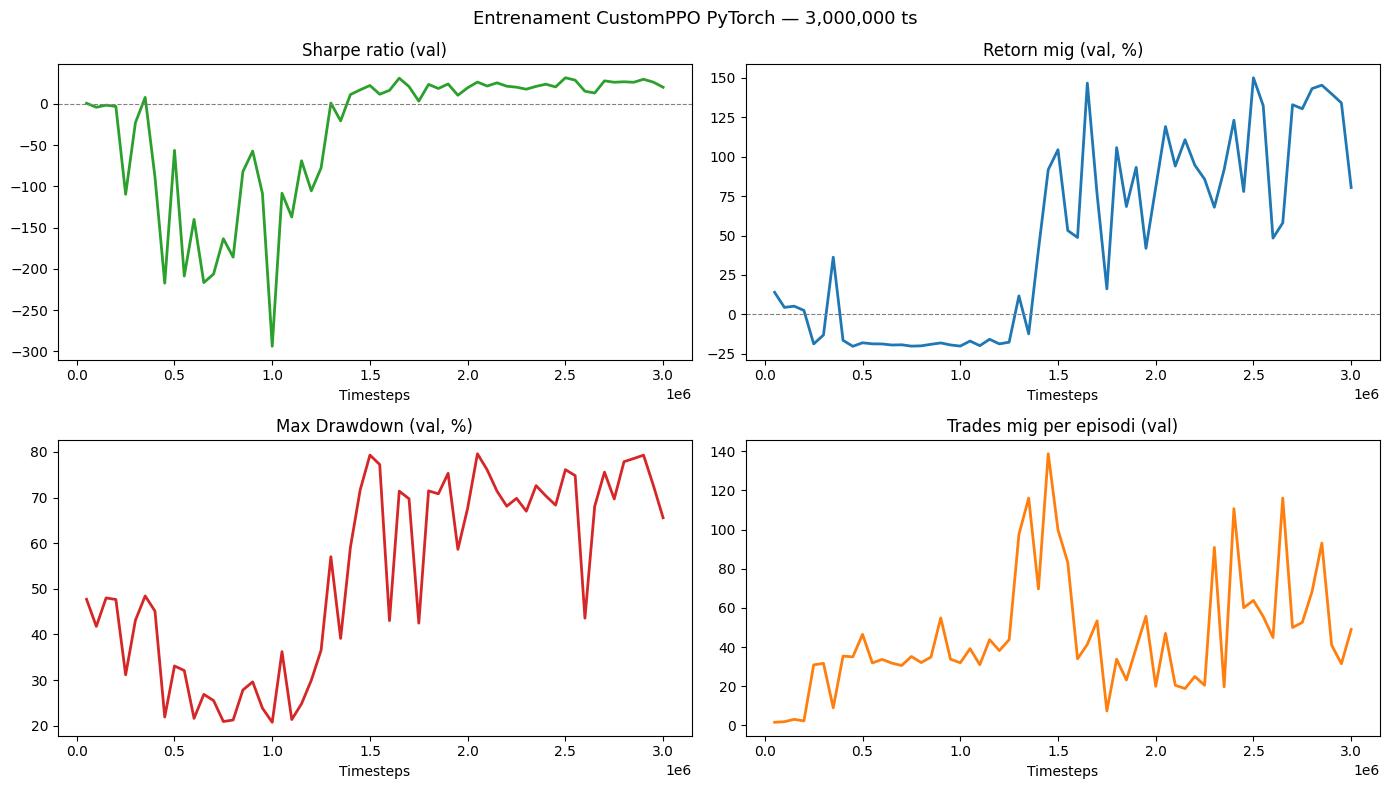

Guardat: results_sparse\03s_ppo_baseline_agent\nb03b_w_a_params_training_curves.png


In [23]:
# =============================================================================
# CEL·LA 23 — VISUALITZACIÓ CORBES D'ENTRENAMENT
# =============================================================================

if eval_history:
    ts_vals    = [h["timestep"]     for h in eval_history]
    sh_vals    = [h["sharpe"]       for h in eval_history]
    ret_vals   = [h["mean_return"]  for h in eval_history]
    dd_vals    = [h["max_drawdown"] for h in eval_history]
    tr_vals    = [h["mean_trades"]  for h in eval_history]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(ts_vals, sh_vals, color="#2ca02c", linewidth=2)
    axes[0, 0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Sharpe ratio (val)"); axes[0, 0].set_xlabel("Timesteps")

    axes[0, 1].plot(ts_vals, ret_vals, color="#1f77b4", linewidth=2)
    axes[0, 1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[0, 1].set_title("Retorn mig (val, %)"); axes[0, 1].set_xlabel("Timesteps")

    axes[1, 0].plot(ts_vals, dd_vals, color="#d62728", linewidth=2)
    axes[1, 0].set_title("Max Drawdown (val, %)"); axes[1, 0].set_xlabel("Timesteps")

    axes[1, 1].plot(ts_vals, tr_vals, color="#ff7f0e", linewidth=2)
    axes[1, 1].set_title("Trades mig per episodi (val)"); axes[1, 1].set_xlabel("Timesteps")

    plt.suptitle(f"Entrenament CustomPPO PyTorch — {FINAL_TIMESTEPS:,} ts", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS / "nb03b_w_a_params_training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Guardat: {RESULTS / 'nb03b_w_a_params_training_curves.png'}")
else:
    print("Sense historial d'avaluació.")


## 4. Avaluació Walk-Forward sobre el Test Split

**Protocol**: l'agent recorre el test split de forma seqüèncial.
- Cada episodi comença on va acabar l'anterior (sense salt enrere)
- L'agent mai ha vist dades del test durant l'entrenament ni el tuning

In [24]:
# =============================================================================
# CEL·LA 24 — DEFINICIÓ DE FUNCIONS: WALK_FORWARD_EVAL
# =============================================================================

def walk_forward_eval(
    model,
    df: pl.DataFrame,
    ep_steps: int = MAX_EPISODE_STEPS,
    seed: int = SEED,
    log_project: "str | None" = None,
    log_dir: Path = RESULTS,
) -> dict:
    """
    Avaluació walk-forward seqüencial sobre df.

    L'agent recorre el dataset d'esquerra a dreta sense overlap temporal.
    Cada episodi comença on va acabar l'anterior (episode_start seqüencial).

    Compatible amb CustomPPO i SB3 PPO (usa model.predict()).

    Args:
        model:    model amb interfície .predict(obs, deterministic)
        df:       dataset de test (Polars DataFrame)
        ep_steps: passos per episodi (= MAX_EPISODE_STEPS)
        seed:     seed per a reproducibilitat

    Returns:
        Dict amb: equities, prices, actions, ep_returns,
                  metrics {total_return, sharpe, max_drawdown,
                           n_episodes, n_steps, action_dist_pct}
    """
    n_rows = len(df)
    all_equities, all_actions, all_prices, ep_returns = [], [], [], []
    start = 0

    env = make_env_consolidated(df, max_episode_steps=ep_steps, seed=None)
    if log_project:
        lp = env.enable_log(project=log_project, log_dir=log_dir)
        print(f"Log CSV (walk-forward): {lp}")

    with torch.no_grad():
        while start + ep_steps + 1 < n_rows:
            obs, info = env.reset(options={"episode_start": start})
            ep_eq = [info["equity"]]
            done  = False

            while not done:
                action, _ = model.predict(obs, deterministic=True)
                obs, _, term, trunc, info = env.step(int(action))
                done = term or trunc
                ep_eq.append(info["equity"])
                all_actions.append(int(action))
                all_prices.append(info["current_price"])

            all_equities.extend(ep_eq)
            ep_returns.append((ep_eq[-1] / ep_eq[0] - 1) * 100)
            start += len(ep_eq) - 1

    if log_project:
        env.disable_log()

    # ── Mètriques agregades ───────────────────────────────────────────────
    eq_arr = np.array(all_equities, dtype=np.float64)
    rets   = np.diff(eq_arr) / (eq_arr[:-1] + 1e-10)
    sharpe = float(rets.mean() / (rets.std() + 1e-10) * np.sqrt(365 * 288))
    max_dd = compute_max_drawdown(all_equities)

    # Retorn acumulat compost dels episodis
    if ep_returns:
        cum = 1.0
        for r in ep_returns:
            cum *= (1 + r / 100)
        tot_ret = (cum - 1) * 100
    else:
        tot_ret = 0.0

    n = len(all_actions)
    act_dist = {
        "HOLD":  all_actions.count(0) / n * 100 if n else 0,
        "LONG":  all_actions.count(1) / n * 100 if n else 0,
        "SHORT": all_actions.count(2) / n * 100 if n else 0,
        "CLOSE": all_actions.count(3) / n * 100 if n else 0,
    }

    return {
        "equities":   all_equities,
        "prices":     all_prices,
        "actions":    all_actions,
        "ep_returns": ep_returns,
        "metrics": {
            "total_return":    tot_ret,
            "sharpe":          sharpe,
            "max_drawdown":    max_dd,
            "n_episodes":      len(ep_returns),
            "n_steps":         n,
            "action_dist_pct": act_dist,
        },
    }


print("walk_forward_eval definit")


walk_forward_eval definit


In [25]:
# =============================================================================
# CEL·LA 25 — AVALUACIÓ WALK-FORWARD
# =============================================================================

print(f"Avaluació walk-forward sobre test split ({len(df_test):,} files)...")
wf_results = walk_forward_eval(
    model_final, df_test,
    log_project=PROJECT + "_test", log_dir=RESULTS,
)
m = wf_results["metrics"]

print()
print("=" * 55)
print("  RESULTATS CustomPPO — TEST SPLIT (walk-forward)")
print("=" * 55)
print(f"  Retorn acumulat:  {m['total_return']:>+8.2f}%")
print(f"  Sharpe ratio:     {m['sharpe']:>+8.4f}")
print(f"  Max drawdown:     {m['max_drawdown']:>8.2f}%")
print(f"  Episodis:         {m['n_episodes']:>8d}")
print(f"  Passos totals:    {m['n_steps']:>8,}")
print("-" * 55)
print("  Distribució accions:")
for k, v in m["action_dist_pct"].items():
    bar = "#" * int(v / 2)
    print(f"    {k:5s}: {v:5.1f}%  {bar}")
print("=" * 55)

# Benchmark B&H (buy-and-hold)
p_arr = np.array(wf_results["prices"], dtype=np.float64)
if len(p_arr) > 0:
    bah = (p_arr[-1] / p_arr[0] - 1) * 100
    print(f"  Buy-and-Hold ref: {bah:>+8.2f}%")
    print(f"  Alpha vs B&H:     {m['total_return'] - bah:>+8.2f}%")


Avaluació walk-forward sobre test split (17,500 files)...
Log CSV (walk-forward): results_sparse\03s_ppo_baseline_agent\1242-260504_nb03s_ppo_pytorch_final_test_log.csv

  RESULTATS CustomPPO — TEST SPLIT (walk-forward)
  Retorn acumulat:  +18295.21%
  Sharpe ratio:      +3.5070
  Max drawdown:        78.95%
  Episodis:                9
  Passos totals:      16,211
-------------------------------------------------------
  Distribució accions:
    HOLD :   0.1%  
    LONG :  40.3%  ####################
    SHORT:  58.3%  #############################
    CLOSE:   1.2%  
  Buy-and-Hold ref:  +138.14%
  Alpha vs B&H:     +18157.07%


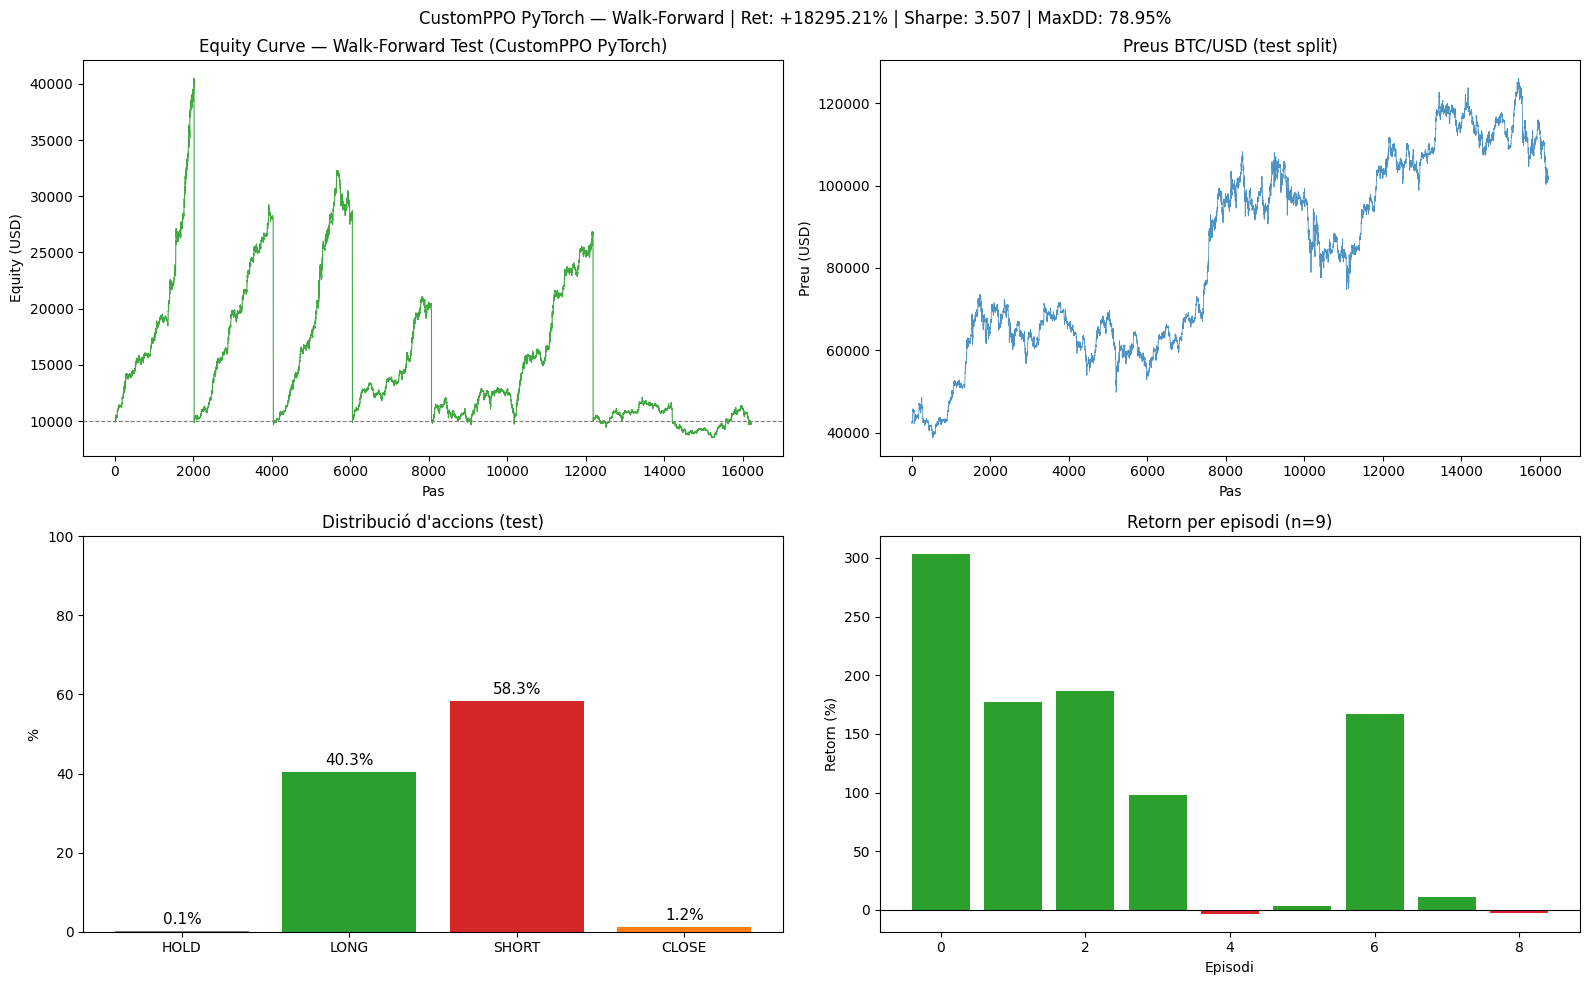

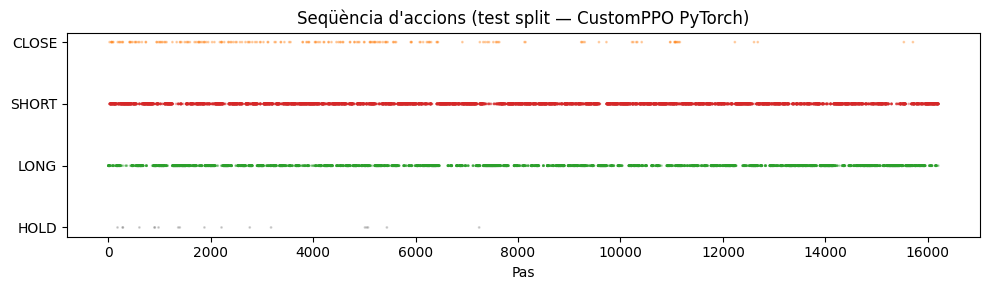

Guardat: results_sparse\03s_ppo_baseline_agent\nb03b_wf_equity_curve.png


In [26]:
# =============================================================================
# CEL·LA 26 — VISUALITZACIÓ WALK-FORWARD
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Corba d'equity
equities = wf_results["equities"]
axes[0, 0].plot(equities, color="#2ca02c", linewidth=0.8, alpha=0.9)
axes[0, 0].axhline(INITIAL_BALANCE, color="gray", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Equity Curve — Walk-Forward Test (CustomPPO PyTorch)")
axes[0, 0].set_xlabel("Pas"); axes[0, 0].set_ylabel("Equity (USD)")

# Preus BTC
prices = wf_results["prices"]
axes[0, 1].plot(prices, color="#1f77b4", linewidth=0.6, alpha=0.8)
axes[0, 1].set_title("Preus BTC/USD (test split)")
axes[0, 1].set_xlabel("Pas"); axes[0, 1].set_ylabel("Preu (USD)")

# Distribució d'accions
act_d = m["action_dist_pct"]
colors_bar = ["#7f7f7f", "#2ca02c", "#d62728", "#ff7f0e"]
bars  = axes[1, 0].bar(act_d.keys(), act_d.values(), color=colors_bar)
axes[1, 0].set_title("Distribució d'accions (test)")
axes[1, 0].set_ylabel("%"); axes[1, 0].set_ylim(0, 100)
for bar, val in zip(bars, act_d.values()):
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{val:.1f}%", ha="center", va="bottom", fontsize=11)

# Retorns per episodi
ep_ret = wf_results["ep_returns"]
axes[1, 1].bar(range(len(ep_ret)),
               ep_ret,
               color=["#2ca02c" if r >= 0 else "#d62728" for r in ep_ret])
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title(f"Retorn per episodi (n={len(ep_ret)})")
axes[1, 1].set_xlabel("Episodi"); axes[1, 1].set_ylabel("Retorn (%)")

plt.suptitle(
    f"CustomPPO PyTorch — Walk-Forward | Ret: {m['total_return']:+.2f}% | "
    f"Sharpe: {m['sharpe']:.3f} | MaxDD: {m['max_drawdown']:.2f}%",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(RESULTS / "nb03b_wf_equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()

# Seqüència d'accions
actions = wf_results["actions"]
fig2, ax2 = plt.subplots(figsize=(10, 3))
colors_map = {0: "#7f7f7f", 1: "#2ca02c", 2: "#d62728", 3: "#ff7f0e"}
ax2.scatter(range(len(actions)), actions,
            c=[colors_map[a] for a in actions], s=1, alpha=0.3)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(["HOLD", "LONG", "SHORT", "CLOSE"])
ax2.set_title("Seqüència d'accions (test split — CustomPPO PyTorch)")
ax2.set_xlabel("Pas")
plt.tight_layout()
plt.savefig(RESULTS / "nb03b_action_dist.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Guardat: {RESULTS / 'nb03b_wf_equity_curve.png'}")


In [28]:
# =============================================================================
# CEL·LA 27 — DESAR MÈTRIQUES
# =============================================================================

# Fallbacks per si alguna secció no s'ha executat en aquesta sessió
_em_opt = float(emissions_optuna) if "emissions_optuna" in globals() else 0.0
_em_fin = float(emissions_final)  if "emissions_final"  in globals() else 0.0
_m      = wf_results["metrics"]   if "wf_results"      in globals() else {}

results_dict = {
    "agent": "PPO-Optuna (CustomPPO PyTorch)",
    "framework": "pytorch+sb3-rolloutbuffer",
    "walk_forward": {
        "train_rows": len(df_train),
        "val_rows":   len(df_val),
        "test_rows":  len(df_test),
    },
    "optuna": {
        "n_trials":        N_TRIALS,
        "tune_ts":         TUNE_TIMESTEPS,
        "best_sharpe_val": float(study.best_value) if "study" in globals() else None,
        "best_params":     best_params_final,
    },
    "training": {
        "final_timesteps": FINAL_TIMESTEPS,
        "hidden_dims":     hidden_dims,
        "n_params":        model_final.policy.count_params(),
    },
    "test_metrics": _m,
    "eval_history": eval_history,
    "sustainability": {
        "emissions_optuna_kg": _em_opt,
        "emissions_final_kg":  _em_fin,
        "emissions_total_kg":  _em_opt + _em_fin,
        "emissions_total_g":   (_em_opt + _em_fin) * 1000,
    },
}

out_path = RESULTS / "nb03s_ppo_pytorch_metrics.json"
with open(out_path, "w") as f:
    json.dump(results_dict, f, indent=2, default=str)

print(f"Resultats desats: {out_path}")
print()
print("RESUM FINAL")
print("=" * 50)
print(f"  Agent:            CustomPPO (PyTorch)")
print(f"  Timesteps:        {FINAL_TIMESTEPS:,}")
print(f"  Hiperparàmetres:  Optuna ({N_TRIALS} trials)")
if _m:
    print(f"  Test retorn:      {_m.get('total_return', float('nan')):+.2f}%")
    print(f"  Test Sharpe:      {_m.get('sharpe', float('nan')):.4f}")
    print(f"  Test MaxDD:       {_m.get('max_drawdown', float('nan')):.2f}%")
print(f"  CO2 total:        {(_em_opt + _em_fin) * 1000:.3f} g CO2eq")
print("=" * 50)
print("NB03s completat")

Resultats desats: results_sparse\03s_ppo_baseline_agent\nb03s_ppo_pytorch_metrics.json

RESUM FINAL
  Agent:            CustomPPO (PyTorch)
  Timesteps:        3,000,000
  Hiperparàmetres:  Optuna (50 trials)
  Test retorn:      +18295.21%
  Test Sharpe:      3.5070
  Test MaxDD:       78.95%
  CO2 total:        62.359 g CO2eq
NB03s completat


In [30]:
# =============================================================================
# VERIFICACIÓ: src.ActorCriticPolicy.load() ≡ model_final.policy
# =============================================================================
# Comprova que carregar el .pt des de src dona resultats idèntics
# a l'avaluació feta directament amb model_final (cel·la 25).
# =============================================================================

from src.rl.agents.actor_critic_policy import ActorCriticPolicy as _ACP_src

# ── Càrrega des de src ────────────────────────────────────────────────────────
CKPT = "checkpoints_sparse/ppo_pytorch_sparse_final.pt"
policy_loaded = _ACP_src.load(CKPT, device=DEVICE)
print(f"Carregat des de src: {policy_loaded.count_params():,} params")

# Verificació ràpida dels pesos: han de ser idèntics als de model_final.policy
for key, w_orig in model_final.policy.state_dict().items():
    w_load = policy_loaded.state_dict()[key]
    assert torch.allclose(w_orig, w_load), f"Divergència en capa: {key}"
print("Pesos idèntics a model_final.policy ✓")

# ── Walk-forward amb la policy carregada ──────────────────────────────────────
wf_loaded = walk_forward_eval(policy_loaded, df_test)
m_orig   = wf_results["metrics"]
m_loaded = wf_loaded["metrics"]

# ── Comparació numèrica ───────────────────────────────────────────────────────
print(f"\n{'='*58}")
print(f"  {'Mètrica':<22} {'model_final':>14} {'src.load()':>14}")
print(f"  {'-'*56}")
for key in ["total_return", "sharpe", "max_drawdown", "n_steps"]:
    v1, v2 = m_orig[key], m_loaded[key]
    ok = "✓" if abs(v1 - v2) < 1e-4 else "✗"
    print(f"  {key:<22} {v1:>+14.4f} {v2:>+14.4f}  {ok}")
print(f"{'='*58}")


print(f"Checkpoints a:")
print(f"{CKPT}")
print(f"Resultats:")
print(f"{out_path}")


Carregat des de src: 35,269 params
Pesos idèntics a model_final.policy ✓

  Mètrica                   model_final     src.load()
  --------------------------------------------------------
  total_return              +18295.2088    +18295.2088  ✓
  sharpe                        +3.5070        +3.5070  ✓
  max_drawdown                 +78.9542       +78.9542  ✓
  n_steps                   +16211.0000    +16211.0000  ✓
Checkpoints a:
checkpoints_sparse/ppo_pytorch_sparse_final.pt
Resultats:
results_sparse\03s_ppo_baseline_agent\nb03s_ppo_pytorch_metrics.json
